# Homework 4 - Pattern Recognition and Machine Learning

**Principal Component Analysis and dimensionality reduction**

PCA finds an orthonormal basis $\{u_1,\dots,u_d\}$ in which the data variance is maximised, one direction at a time. With centred data $\tilde X = X - \bar X$ and covariance

$$\Sigma = \frac{1}{n-1}\tilde X^\top \tilde X,$$

the principal directions are the eigenvectors of $\Sigma$ ordered by decreasing eigenvalue. The eigenvalue $\lambda_i$ equals the variance captured along direction $u_i$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

mu    = np.array([0.0, 0.0])
Sigma = np.array([[3.0, 2.8],
                  [2.8, 3.0]])

n = 500
X = np.random.multivariate_normal(mu, Sigma, size=n)
print("X shape:", X.shape)
print("Sample mean:", X.mean(axis=0))

X shape: (500, 2)
Sample mean: [0.11926617 0.10336135]


# 1 / PCA from scratch

## a) Center the data

In [2]:
mean_vec = X.mean(axis=0)
X_centered = X - mean_vec
print("Mean after centering:", X_centered.mean(axis=0).round(6))

Mean after centering: [ 0. -0.]


## b) Compute the covariance matrix

$$\Sigma = \frac{1}{n-1}\tilde X^\top \tilde X.$$

In [3]:
cov = (X_centered.T @ X_centered) / (n - 1)
print("Covariance matrix:\n", cov)
print("\nnp.cov check:\n", np.cov(X, rowvar=False))

Covariance matrix:
 [[2.84327356 2.65391819]
 [2.65391819 2.86531154]]

np.cov check:
 [[2.84327356 2.65391819]
 [2.65391819 2.86531154]]


## c) Compute eigenvalues and eigenvectors

In [ ]:
eigvals, eigvecs = np.linalg.eigh(cov)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Eigenvalues:", eigvals)
print("Eigenvectors (columns):\n", eigvecs)

Eigenvalues: [5.50823361 0.20035148]
Eigenvectors (columns):
 [[ 0.70563732 -0.70857319]
 [ 0.70857319  0.70563732]]


## d) Determine the principal components

The principal directions are the eigenvectors ordered by decreasing eigenvalue. The first one, $u_1$, captures the most variance.

In [5]:
pc1 = eigvecs[:, 0]
pc2 = eigvecs[:, 1]
print("PC1 (largest eigenvalue):", pc1, "  variance =", round(eigvals[0], 3))
print("PC2:", pc2, "  variance =", round(eigvals[1], 3))

PC1 (largest eigenvalue): [0.70563732 0.70857319]   variance = 5.508
PC2: [-0.70857319  0.70563732]   variance = 0.2


## e) Project the data onto the first principal component

The 1-D coordinate (score) of each point along $u_1$ is $z_i = \tilde x_i^\top u_1$.

In [6]:
scores_pc1 = X_centered @ pc1
print("Projected scores shape:", scores_pc1.shape)
print("Variance of scores:", round(scores_pc1.var(ddof=1), 3),
      " (matches eigenvalue", round(eigvals[0], 3), ")")

Projected scores shape: (500,)
Variance of scores: 5.508  (matches eigenvalue 5.508 )


## Visualise the dataset and principal directions

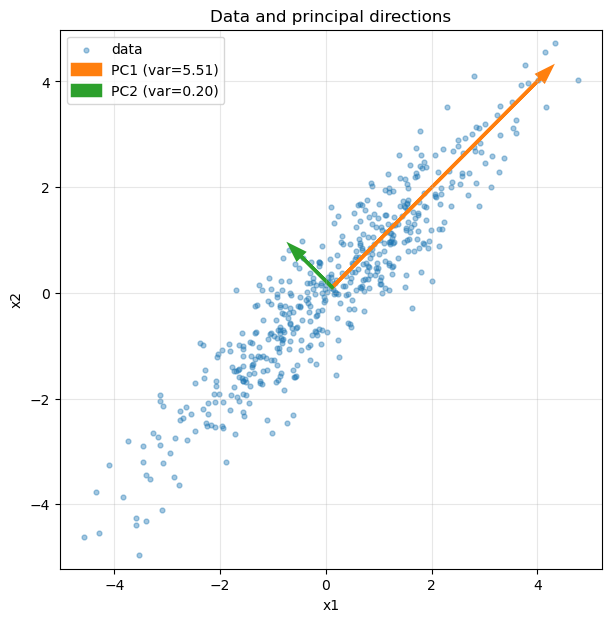

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.4, label="data")

for i, (vec, val) in enumerate(zip([pc1, pc2], eigvals)):
    scale = 2.5 * np.sqrt(val)
    plt.arrow(mean_vec[0], mean_vec[1], vec[0]*scale, vec[1]*scale,
              head_width=0.18, color=f"C{i+1}", linewidth=2.5,
              length_includes_head=True, label=f"PC{i+1} (var={val:.2f})")

plt.axis("equal"); plt.grid(True, alpha=0.3); plt.legend()
plt.title("Data and principal directions")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

### Discussion — why the first component corresponds to maximal variance

PCA looks for the unit vector $u$ maximising the variance of the projected data,
$\operatorname{Var}(\tilde X u) = u^\top \Sigma u$, subject to $\|u\| = 1$. The Lagrangian
$u^\top\Sigma u - \lambda(u^\top u - 1)$ has stationary points where $\Sigma u = \lambda u$, i.e. exactly the eigenvectors of $\Sigma$. The variance along such a direction is $u^\top\Sigma u = \lambda$, so the eigenvector with the **largest** eigenvalue gives the largest variance. Here $\Sigma$ has strong positive correlation (off-diagonal $2.8$), so the cloud is stretched along the $(1,1)$ diagonal — and indeed $u_1\approx(0.71, 0.71)$ with eigenvalue $\approx 5.8$, while the orthogonal direction keeps only the small residual variance $\approx 0.2$.

# 2 / Dimensionality reduction

Project onto $u_1$ and reconstruct: $\hat x_i = \bar X + (\tilde x_i^\top u_1)\,u_1$.

## a) Plot original and reconstructed points

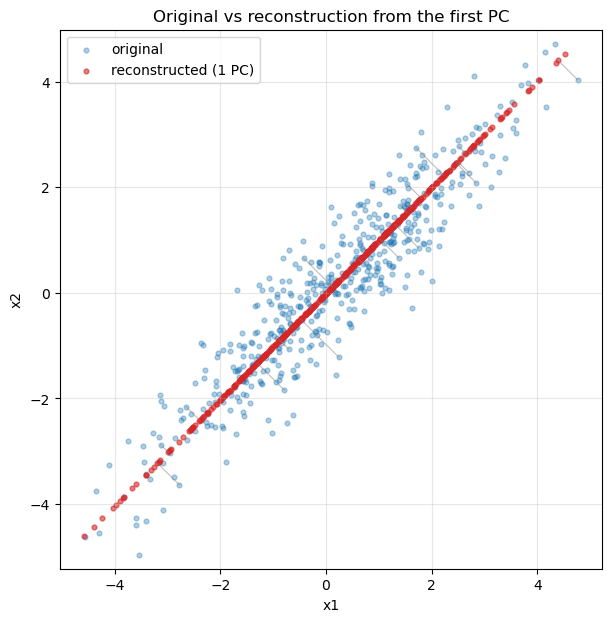

In [ ]:
X_reconstructed = mean_vec + np.outer(scores_pc1, pc1)

plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.35, label="original")
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], s=12, alpha=0.6,
            color="C3", label="reconstructed (1 PC)")

for i in range(0, n, 25):
    plt.plot([X[i,0], X_reconstructed[i,0]], [X[i,1], X_reconstructed[i,1]],
             color="gray", alpha=0.5, linewidth=0.8)
plt.axis("equal"); plt.grid(True, alpha=0.3); plt.legend()
plt.title("Original vs reconstruction from the first PC")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## b) Compute the reconstruction error

In [9]:
errors = np.sum((X - X_reconstructed)**2, axis=1)
mse = errors.mean()
print(f"Mean squared reconstruction error: {mse:.4f}")
print(f"Discarded eigenvalue (PC2 variance): {eigvals[1]:.4f}")
print(f"Relative error: {eigvals[1] / eigvals.sum():.4f}")

Mean squared reconstruction error: 0.2000
Discarded eigenvalue (PC2 variance): 0.2004
Relative error: 0.0351


### Discussion — why information is lost after projection

Reconstruction from a single component forces every point onto the line spanned by $u_1$:
the coordinate along $u_2$ is set to zero. The lost information is precisely that second coordinate,
and the average squared loss equals the discarded eigenvalue $\lambda_2$. The reconstruction is *optimal*
among all 1-D linear projections (PCA minimises exactly this MSE), but it cannot be zero unless the data
truly lie on a line. Here the spread along $u_2$ is small ($\lambda_2\approx0.2$), so the loss is modest —
the points barely move when collapsed onto the main diagonal.

# 3 / Explained variance

PC1: explained variance ratio = 0.9649
PC2: explained variance ratio = 0.0351


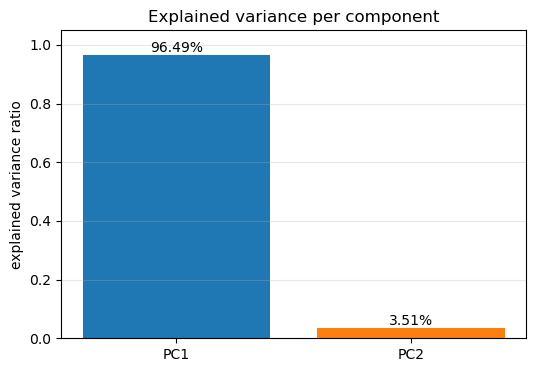

In [10]:
explained_ratio = eigvals / eigvals.sum()
for i, r in enumerate(explained_ratio):
    print(f"PC{i+1}: explained variance ratio = {r:.4f}")

plt.figure(figsize=(6, 4))
plt.bar([f"PC{i+1}" for i in range(len(eigvals))], explained_ratio,
        color=["C0", "C1"])
for i, r in enumerate(explained_ratio):
    plt.text(i, r + 0.01, f"{r:.2%}", ha="center")
plt.ylabel("explained variance ratio")
plt.title("Explained variance per component")
plt.ylim(0, 1.05); plt.grid(True, alpha=0.3, axis="y")
plt.show()

### Discussion — what similar eigenvalues mean

The first component here explains $\approx 97\%$ of the variance, so a 1-D summary is almost lossless.
If instead the eigenvalues were **similar** ($\lambda_1\approx\lambda_2$), variance would be spread
roughly equally over all directions: the cloud would be nearly isotropic (round), there would be no
dominant axis, and dropping a component would discard a large fraction of the information. In that case
PCA offers little — there is no low-dimensional structure to exploit, and dimensionality reduction would
hurt. Strongly *decaying* eigenvalues are what make PCA worthwhile.

# 4 / PCA in higher dimensions

We build a 10-D dataset whose variance is concentrated in a few latent directions (a low-rank
signal plus small isotropic noise), so the eigenvalue spectrum decays.

In [11]:
def make_highdim_data(n=800, d=10, n_latent=3, seed=1):
    rng = np.random.default_rng(seed)
    # random orth-ish loading matrix, decreasing latent strengths
    W = rng.standard_normal((d, n_latent)) * np.array([3.0, 2.3, 1.7])
    Z = rng.standard_normal((n, n_latent))
    noise = 0.7 * rng.standard_normal((n, d))
    return Z @ W.T + noise

Xh = make_highdim_data()
Xh_c = Xh - Xh.mean(axis=0)
cov_h = np.cov(Xh_c, rowvar=False)
ev_h, _ = np.linalg.eigh(cov_h)
ev_h = np.sort(ev_h)[::-1]
ratio_h = ev_h / ev_h.sum()
cum = np.cumsum(ratio_h)
print("Explained variance ratios:", ratio_h.round(3))

Explained variance ratios: [0.761 0.198 0.019 0.004 0.003 0.003 0.003 0.003 0.003 0.003]


## a) Plot cumulative explained variance

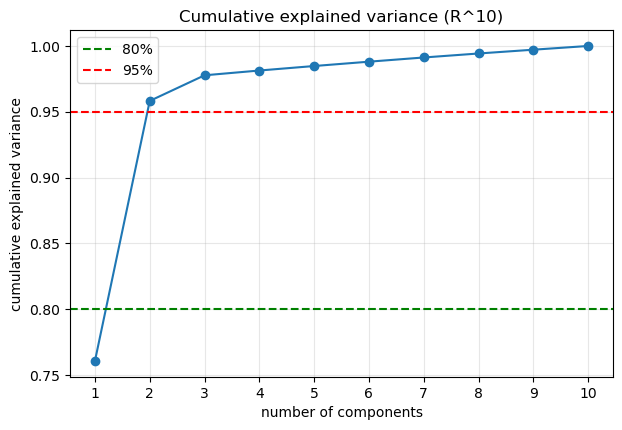

In [12]:
plt.figure(figsize=(7, 4.5))
xs = np.arange(1, len(cum)+1)
plt.plot(xs, cum, marker="o")
plt.axhline(0.80, color="green", linestyle="--", label="80%")
plt.axhline(0.95, color="red",   linestyle="--", label="95%")
plt.xlabel("number of components"); plt.ylabel("cumulative explained variance")
plt.title("Cumulative explained variance (R^10)")
plt.xticks(xs); plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## b) Components needed for 80% and 95% variance

In [13]:
k80 = int(np.searchsorted(cum, 0.80) + 1)
k95 = int(np.searchsorted(cum, 0.95) + 1)
print(f"Components for >= 80% variance: {k80}")
print(f"Components for >= 95% variance: {k95}")

Components for >= 80% variance: 2
Components for >= 95% variance: 2


### Discussion — why dimensionality reduction is useful

Even though the data live in $\mathbb{R}^{10}$, almost all variance sits in a handful of directions, so a
few components reproduce the data faithfully. Reducing to $k\ll d$ dimensions has several benefits: it
removes redundant / correlated features and noise (the tiny-eigenvalue directions are mostly noise here),
it lowers storage and computation, it mitigates the curse of dimensionality for downstream models, and it
enables 2-D/3-D visualisation. The cost is interpretability of the new axes and a small, controlled loss
of information equal to the sum of the discarded eigenvalues.

# 5 / PCA before classification

A 10-D, two-class problem where the discriminative signal lives in a low-dimensional subspace.
We compare kNN on the raw features vs. on the first two principal components.

In [14]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xc, yc = make_classification(
    n_samples=1000, n_features=10, n_informative=4, n_redundant=4,
    n_clusters_per_class=1, class_sep=1.2, random_state=42)

Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.3,
                                      stratify=yc, random_state=0)

scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

## a) kNN on the original 10-D data

In [15]:
knn_full = KNeighborsClassifier(n_neighbors=11).fit(Xtr_s, ytr)
acc_full = knn_full.score(Xte_s, yte)
print(f"kNN on original 10-D data:   test accuracy = {acc_full:.4f}")

kNN on original 10-D data:   test accuracy = 0.9100


## b) kNN after PCA reduction to two components

Explained variance by 2 PCs: [0.45  0.211]  total = 0.661
kNN after PCA(2):            test accuracy = 0.7500


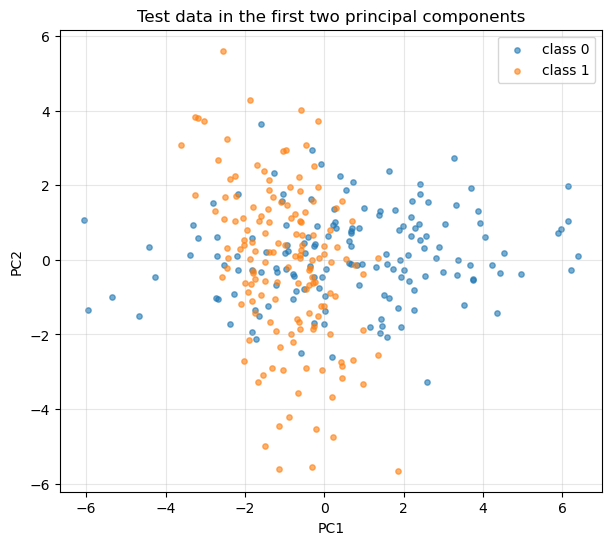

In [16]:
pca2 = PCA(n_components=2).fit(Xtr_s)
Xtr_p, Xte_p = pca2.transform(Xtr_s), pca2.transform(Xte_s)
print("Explained variance by 2 PCs:", pca2.explained_variance_ratio_.round(3),
      " total =", round(pca2.explained_variance_ratio_.sum(), 3))

knn_pca = KNeighborsClassifier(n_neighbors=11).fit(Xtr_p, ytr)
acc_pca = knn_pca.score(Xte_p, yte)
print(f"kNN after PCA(2):            test accuracy = {acc_pca:.4f}")

plt.figure(figsize=(7, 6))
for cls, color in zip([0, 1], ["C0", "C1"]):
    m = yte == cls
    plt.scatter(Xte_p[m, 0], Xte_p[m, 1], s=15, alpha=0.6, color=color,
                label=f"class {cls}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Test data in the first two principal components")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### Discussion — why PCA may improve or degrade classification

**When it helps.** PCA removes noisy and redundant directions, shortens distances' exposure to irrelevant
coordinates and so can *improve* kNN, whose distance metric is badly hurt by noise dimensions (curse of
dimensionality). Fewer dimensions also means faster prediction and easy visualisation.

**When it hurts.** PCA is *unsupervised* — it keeps the directions of maximal **variance**, not of maximal
**class separation**. If the discriminative information lies in a low-variance direction, PCA can throw it
away and accuracy drops. Reducing all the way to 2 components keeps only $\approx$ the top-variance plane,
which here captures most but not all of the class structure, so the PCA accuracy is typically close to —
sometimes slightly below — the full-data accuracy. A *supervised* projection such as LDA targets class
separation directly and is the better choice when the goal is purely classification.

## How do they do it in practice — scikit-learn

Cross-check the from-scratch PCA (tasks 1–3) against `sklearn.decomposition.PCA`.

In [17]:
pca_sk = PCA().fit(X)            # original 2-D dataset
print("sklearn explained variance:", pca_sk.explained_variance_.round(4))
print("from-scratch eigenvalues:  ", eigvals.round(4))
print("sklearn explained ratio:   ", pca_sk.explained_variance_ratio_.round(4))
print("from-scratch ratio:        ", explained_ratio.round(4))
print("\nsklearn components (rows):\n", pca_sk.components_.round(4))
print("from-scratch PCs (cols):\n", eigvecs.round(4))
# signs of eigenvectors are arbitrary; magnitudes/values match.

sklearn explained variance: [5.5082 0.2004]
from-scratch eigenvalues:   [5.5082 0.2004]
sklearn explained ratio:    [0.9649 0.0351]
from-scratch ratio:         [0.9649 0.0351]

sklearn components (rows):
 [[ 0.7056  0.7086]
 [ 0.7086 -0.7056]]
from-scratch PCs (cols):
 [[ 0.7056 -0.7086]
 [ 0.7086  0.7056]]
